In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import os
from importlib import reload

import FACET2_S2E as qs
from pmd_beamphysics import ParticleGroup

from Experimental_functions import *
import FACET2_S2E_Kladov as kladov

# Helper function to properly reload kladov and all its submodules
def reload_kladov():
    """Reload kladov module and all its submodules"""
    # Reload submodules first
    if 'FACET2_S2E_Kladov.UTILITY_quickstart' in sys.modules:
        reload(sys.modules['FACET2_S2E_Kladov.UTILITY_quickstart'])
    if 'FACET2_S2E_Kladov.functionsForSims' in sys.modules:
        reload(sys.modules['FACET2_S2E_Kladov.functionsForSims'])
    # Then reload the main module
    reload(kladov)
    return kladov

#filepath = str(Path(os.getcwd()).parent)
filepath = "/sdf/group/facet/kladov/FACET2-S2E"
folder = "/sdf/group/facet/kladov/FACET2-S2E/"

print(os.system("hostname"))

def get_energy_at_checkpoints(tao, locationsToSave):
    energy_at_checkpoints = []
    for location in locationsToSave:
        energy_at_checkpoints.append(float(np.mean(kladov.getBeamAtElement(tao, location).pz))/1e6)
    return energy_at_checkpoints

sdfmilan101
0


In [2]:
reload_kladov()
tao = kladov.initializeTao(filePath = filepath)

current_e_start = tao.ele_gen_attribs('L0AFEND')["P0C"]*1e-6
folder = filepath + "/"
file = folder+ "temp_beam/temp"
moments = [0 for i in range(6)]
kladov.make_simple_bunch_standalone(N=1e2, meanPzMeV = current_e_start, moments=moments, save_path = file)

kladov.set_beam(tao, file)

print(kladov.get_rij(tao, 'BX0FBEG', 'BPM10731', i=1, j=6))
tao = kladov.run_initialized_sim(tao, start='L0AFEND', finish='BPM10731')
print(get_energy_at_checkpoints(tao, ["L0AFEND", "BPM10731"]))
print(float(np.mean(kladov.getBeamAtElement(tao, 'BPM10731').x))*1e3)


Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Base Tao lattice
CSR off, SC off
-0.2627814
[63.99795996805204, 124.99895603193167]
-1.2518277713531508e-06


In [6]:
reload_kladov()
tao = kladov.initializeTao(filePath = filepath)
kladov.set_beam(tao, file)

tao.cmd(f'set ele {'BX10661'} B_FIELD = {0}')

print(kladov.get_rij(tao, 'BX0FBEG', 'BPM10731', i=1, j=6))

tao = kladov.run_initialized_sim(tao, start='L0AFEND', finish='BPM10731')
print(get_energy_at_checkpoints(tao, ["L0AFEND", "BPM10731"]))
print(float(np.mean(kladov.getBeamAtElement(tao, 'BPM10731').x))*1e3)

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Base Tao lattice
CSR off, SC off
-0.0
[63.99795996805204, 124.99895540981258]
1.130204383085998e-07


In [8]:
reload_kladov()
tao = kladov.initializeTao(filePath = filepath)
kladov.set_beam(tao, file)

l0bVoltage = tao.ele_gen_attribs('L0BF')["VOLTAGE"]
tao.cmd(f'set ele L0BF VOLTAGE = {l0bVoltage*0.8}')

print(kladov.get_rij(tao, 'BX0FBEG', 'BPM10731', i=1, j=6))
tao = kladov.run_initialized_sim(tao, start='L0AFEND', finish='BPM10731')
print(get_energy_at_checkpoints(tao, ["L0AFEND", "BPM10731"]))
print(float(np.mean(kladov.getBeamAtElement(tao, 'BPM10731').x))*1e3)

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Base Tao lattice
CSR off, SC off
-0.2627814
[63.99795996805204, 112.79884246719742]
-3.213751904455455e-07


In [18]:
reload_kladov()
tao = kladov.initializeTao(filePath = filepath)
kladov.set_beam(tao, file)

tao.cmd(f'set global lattice_calc_on = F')
tao.cmd(f'set ele {'BX10661'} B_FIELD = {0}')
tao.cmd(f'set ele {'BX10661'} E1 = {0}')
tao.cmd(f'set ele {'BX10661'} E2 = {0}')
tao.cmd(f'set ele {'BX10661'} FINT = {0}')
tao.cmd(f'set ele {'BX10661'} FINTX = {0}')
tao.cmd(f'set global lattice_calc_on = T')

print(kladov.get_rij(tao, 'BX0FBEG', 'BPM10731', i=1, j=6))

tao = kladov.run_initialized_sim(tao, start='L0AFEND', finish='BPM10731', locations=None)
print(get_energy_at_checkpoints(tao, ["L0AFEND", "BPM10731"]))
print(float(np.mean(kladov.getBeamAtElement(tao, 'BPM10731').x))*1e3)

Environment set to:  /sdf/group/facet/kladov/FACET2-S2E
-init /sdf/group/facet/kladov/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
Base Tao lattice
CSR off, SC off
-0.0
[63.99795996805204, 124.99895554218259]
-4.3135091117221506e-08


In [19]:
tao.ele_gen_attribs('BX10661')

{'L': 0.2039920020036741,
 'units#L': 'm',
 'ROLL': 0.0,
 'units#ROLL': 'rad',
 'REF_TILT': 0.0,
 'units#REF_TILT': 'rad',
 'K1': 0.0,
 'units#K1': '1/m^2',
 'K2': 0.0,
 'units#K2': '1/m^3',
 'G': 0.0,
 'units#G': '1/m',
 'DG': 0.0,
 'units#DG': '1/m',
 'G_TOT': 0.0,
 'units#G_TOT': '1/m',
 'RHO': 0.0,
 'units#RHO': 'm',
 'FRINGE_TYPE': 'Full',
 'FRINGE_AT': 'Both_Ends',
 'SPIN_FRINGE_ON': True,
 'EXACT_MULTIPOLES': 'Off',
 'R0_ELEC': 0.0,
 'units#R0_ELEC': 'm',
 'R0_MAG': 0.0,
 'units#R0_MAG': 'm',
 'STATIC_LINEAR_MAP': False,
 'E1': 0.0,
 'units#E1': 'rad',
 'E2': 0.0,
 'units#E2': 'rad',
 'FINT': 0.0,
 'units#FINT': '',
 'FINTX': 0.0,
 'units#FINTX': '',
 'HGAP': 0.015,
 'units#HGAP': 'm',
 'HGAPX': 0.015,
 'units#HGAPX': 'm',
 'H1': 0.0,
 'units#H1': '1/m',
 'H2': 0.0,
 'units#H2': '1/m',
 'L_RECTANGLE': 0.2039920020036741,
 'units#L_RECTANGLE': 'm',
 'B_FIELD_TOT': 0.0,
 'units#B_FIELD_TOT': 'T',
 'L_SAGITTA': 0.0,
 'units#L_SAGITTA': 'm',
 'L_CHORD': 0.2039920020036741,
 'units#L

PR11375
Bunch energy will be 87.51235727396336 MeV
125.00162874004609
-0.6678876020631938
-0.305428640048888
0.6242974874838839


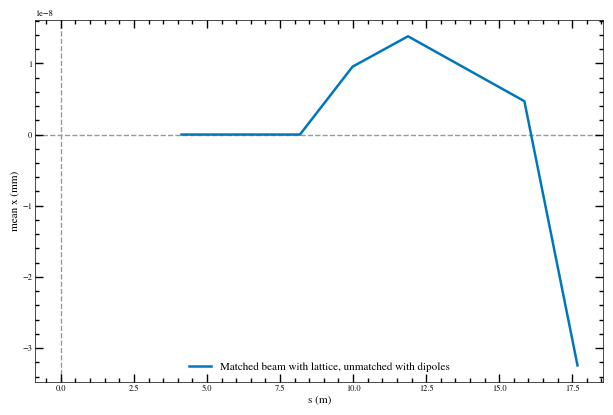

[87.51235727396335, 125.00162876544083]
-3.3384848421300816e-08


In [7]:
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, start='L0AFEND', filepath=filepath,
                                    verbose=False, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", run=False)

print(tao.ele_gen_attribs('BX10661')["P0C"]*1e-6)
print(tao.ele_gen_attribs('BX10661')["RHO"])
print(tao.ele_gen_attribs('BX10661')["ANGLE"])
print(tao.ele_gen_attribs('BX10661')["B_FIELD"])

tao = kladov.run_initialized_sim(tao, start='L0AFEND', finish='BPM10731')

s = tao.bunch_comb("s")
mean_x = tao.bunch_comb("x")
kladov.make_a_plot(s, mean_x*1e3, x_label="s (m)", y_label="mean x (mm)", label="Matched beam with lattice, unmatched with dipoles")

print(get_energy_at_checkpoints(tao, ["L0AFEND", "BPM10731"]))
print(float(np.mean(kladov.getBeamAtElement(tao, 'BPM10731').x))*1e3)

PR11375
Bunch energy will be 87.51235727396336 MeV
128.75054155580668
-0.6879148346400821
-0.2965367102606575
0.6243005054950508


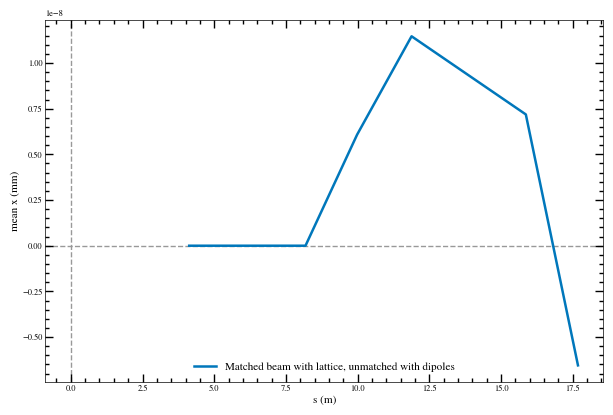

[87.51235727396335, 128.75054155228764]
-6.7261791836358985e-09


In [8]:
reload_kladov()
experiment="BEAMPHYS"
scan_number="14438"
date="/2026/20260121"
tao = kladov.get_tao_from_experiment(experiment=experiment, scan_number=scan_number, date=date, start='L0AFEND', filepath=filepath,
                                    verbose=False, lattice="setLattice_configs/2024-10-22_oneBunch-Copy1.yml", run=False)

print(tao.ele_gen_attribs('BX10661')["P0C"]*1e-6)
print(tao.ele_gen_attribs('BX10661')["RHO"])
print(tao.ele_gen_attribs('BX10661')["ANGLE"])
print(tao.ele_gen_attribs('BX10661')["B_FIELD"])

tao = kladov.run_initialized_sim(tao, start='L0AFEND', finish='BPM10731')

s = tao.bunch_comb("s")
mean_x = tao.bunch_comb("x")
kladov.make_a_plot(s, mean_x*1e3, x_label="s (m)", y_label="mean x (mm)", label="Matched beam with lattice, unmatched with dipoles")

print(get_energy_at_checkpoints(tao, ["L0AFEND", "BPM10731"]))
print(float(np.mean(kladov.getBeamAtElement(tao, 'BPM10731').x))*1e3)